# Structured Streaming using the Python DataFrames API

Apache Spark includes a high-level stream processing API, [Structured Streaming](http://spark.apache.org/docs/latest/structured-streaming-programming-guide.html). In this notebook we take a quick look at how to use the DataFrame API to build Structured Streaming applications. We want to compute real-time metrics like running counts and windowed counts on a stream of timestamped actions (e.g. Open, Close, etc).

To run this notebook, import it and attach it to a Spark cluster.

## Sample Data
We have some sample action data as files in `/databricks-datasets/structured-streaming/events/` which we are going to use to build this appication. Let's take a look at the contents of this directory.

In [0]:
# Look at the content of the following folder: /databricks-datasets/structured-streaming/events/
# using the following command: display(dbutils.fs.ls('dbfs:/databricks-datasets/structured-streaming/events/')
# What do you see?
display(dbutils.fs.ls('dbfs:/databricks-datasets/structured-streaming/events/'))

path,name,size,modificationTime
dbfs:/databricks-datasets/structured-streaming/events/file-0.json,file-0.json,72530,1596690605000
dbfs:/databricks-datasets/structured-streaming/events/file-1.json,file-1.json,72961,1596690605000
dbfs:/databricks-datasets/structured-streaming/events/file-10.json,file-10.json,73025,1596690605000
dbfs:/databricks-datasets/structured-streaming/events/file-11.json,file-11.json,72999,1596690605000
dbfs:/databricks-datasets/structured-streaming/events/file-12.json,file-12.json,72987,1596690605000
dbfs:/databricks-datasets/structured-streaming/events/file-13.json,file-13.json,73006,1596690605000
dbfs:/databricks-datasets/structured-streaming/events/file-14.json,file-14.json,73003,1596690605000
dbfs:/databricks-datasets/structured-streaming/events/file-15.json,file-15.json,73007,1596690605000
dbfs:/databricks-datasets/structured-streaming/events/file-16.json,file-16.json,72978,1596690605000
dbfs:/databricks-datasets/structured-streaming/events/file-17.json,file-17.json,73008,1596690605000


There are about 50 JSON files in the directory. Let's see what each JSON file contains.

In [0]:
# Look at the functions head in dbutils
# Open one file
dbutils.help()


This module provides various utilities for users to interact with the rest of Databricks.
 credentials: DatabricksCredentialUtils -> Utilities for interacting with credentials within notebooks data: DataUtils -> Utilities for understanding and interacting with datasets (EXPERIMENTAL) fs: DbfsUtils -> Manipulates the Databricks filesystem (DBFS) from the console jobs: JobsUtils -> Utilities for leveraging jobs features library: LibraryUtils -> Utilities for session isolated libraries meta: MetaUtils -> Methods to hook into the compiler (EXPERIMENTAL) notebook: NotebookUtils -> Utilities for the control flow of a notebook (EXPERIMENTAL) preview: Preview -> Utilities under preview category secrets: SecretUtils -> Provides utilities for leveraging secrets within notebooks widgets: WidgetsUtils -> Methods to create and get bound value of input widgets inside notebooks

In [0]:
dbutils.fs.head('dbfs:/databricks-datasets/structured-streaming/events/file-0.json')

[Truncated to first 65536 bytes]


'{"time":1469501107,"action":"Open"}\n{"time":1469501147,"action":"Open"}\n{"time":1469501202,"action":"Open"}\n{"time":1469501219,"action":"Open"}\n{"time":1469501225,"action":"Open"}\n{"time":1469501234,"action":"Open"}\n{"time":1469501245,"action":"Open"}\n{"time":1469501246,"action":"Open"}\n{"time":1469501248,"action":"Open"}\n{"time":1469501256,"action":"Open"}\n{"time":1469501264,"action":"Open"}\n{"time":1469501266,"action":"Open"}\n{"time":1469501267,"action":"Open"}\n{"time":1469501269,"action":"Open"}\n{"time":1469501271,"action":"Open"}\n{"time":1469501282,"action":"Open"}\n{"time":1469501285,"action":"Open"}\n{"time":1469501291,"action":"Open"}\n{"time":1469501297,"action":"Open"}\n{"time":1469501303,"action":"Open"}\n{"time":1469501322,"action":"Open"}\n{"time":1469501335,"action":"Open"}\n{"time":1469501344,"action":"Open"}\n{"time":1469501346,"action":"Open"}\n{"time":1469501349,"action":"Open"}\n{"time":1469501357,"action":"Open"}\n{"time":1469501366,"action":"Open"}\n

Each line in the file contains JSON record with two fields - `time` and `action`. Let's try to analyze these files interactively.

## Batch/Interactive Processing
The usual first step in attempting to process the data is to interactively query the data. Let's define a static DataFrame on the files, and give it a table name.

In [0]:
from pyspark.sql.types import *

inputPath = "/databricks-datasets/structured-streaming/events/"

# Since we know the data format already, let's define the schema to speed up processing (no need for Spark to infer schema)
jsonSchema = StructType(
  [ StructField("time", TimestampType(), True),
   StructField("action", StringType(), True) ]
)



In [0]:
# Read all json files, taking into account the defined schema, and display the content 
# Read all JSON files at the path
df = spark.read.schema(jsonSchema).json(inputPath)

# Display the content
display(df)

time,action
2016-07-28T04:19:28.000Z,Close
2016-07-28T04:19:28.000Z,Close
2016-07-28T04:19:29.000Z,Open
2016-07-28T04:19:31.000Z,Close
2016-07-28T04:19:31.000Z,Open
2016-07-28T04:19:31.000Z,Open
2016-07-28T04:19:32.000Z,Close
2016-07-28T04:19:33.000Z,Close
2016-07-28T04:19:35.000Z,Close
2016-07-28T04:19:36.000Z,Open


In [0]:
df_no_schema = spark.read.json(inputPath)
display(df_no_schema)


action,time
Close,1469679568
Close,1469679568
Open,1469679569
Close,1469679571
Open,1469679571
Open,1469679571
Close,1469679572
Close,1469679573
Close,1469679575
Open,1469679576


- Compare the dates from the output without schema and with it. 
- Did you notice that inputPath is a folder?

The date are normalize with the shemat one's and not with the other

In [0]:
# Calculate the total number of 'Open' and 'Close' actions 
df.groupBy("action").count().display()

action,count
Close,50000
Open,50000


In [0]:
# Determine min and max time
from pyspark.sql.functions import min, max

df.agg(min("time"), max("time")).display()

min(time),max(time)
2016-07-26T02:45:07.000Z,2016-07-28T06:48:19.000Z


In [0]:
# Calculate the number of "open" and "close" actions with one hour windows: staticCountsDF
# Look at groupBy(..., window) function
from pyspark.sql.functions import window

staticCountsDF=df.groupBy("action", window("time", "1 hour")).count()


In [0]:
# Make this window a sliding window (30 minutes overlap): staticCountsSW

staticCountsSW=df.groupBy("action", window("time", "30 minutes")).count()


In [0]:
# Register staticCountsDF (createOrReplaceTempView) as table 'static_counts'
staticCountsDF.createOrReplaceTempView("static_counts")

Now we can directly use SQL to query the table.

In [0]:
%sql
-- Count all Open and Close actions in the table static_counts 
select action, SUM(count) as total_count 
from static_counts 
group by action


action,total_count
Close,50000
Open,50000


In [0]:
%sql
-- How many actions (Close and Open separately) is within each time window (in the table static_counts)
-- Make a plot
SELECT *
FROM static_counts;



action,window,count
Close,"List(2016-07-28T04:00:00.000Z, 2016-07-28T05:00:00.000Z)",960
Open,"List(2016-07-28T04:00:00.000Z, 2016-07-28T05:00:00.000Z)",825
Close,"List(2016-07-27T13:00:00.000Z, 2016-07-27T14:00:00.000Z)",986
Open,"List(2016-07-26T13:00:00.000Z, 2016-07-26T14:00:00.000Z)",1006
Close,"List(2016-07-26T13:00:00.000Z, 2016-07-26T14:00:00.000Z)",1028
Close,"List(2016-07-26T14:00:00.000Z, 2016-07-26T15:00:00.000Z)",994
Open,"List(2016-07-27T04:00:00.000Z, 2016-07-27T05:00:00.000Z)",995
Close,"List(2016-07-27T20:00:00.000Z, 2016-07-27T21:00:00.000Z)",1025
Open,"List(2016-07-27T20:00:00.000Z, 2016-07-27T21:00:00.000Z)",1005
Close,"List(2016-07-27T21:00:00.000Z, 2016-07-27T22:00:00.000Z)",979


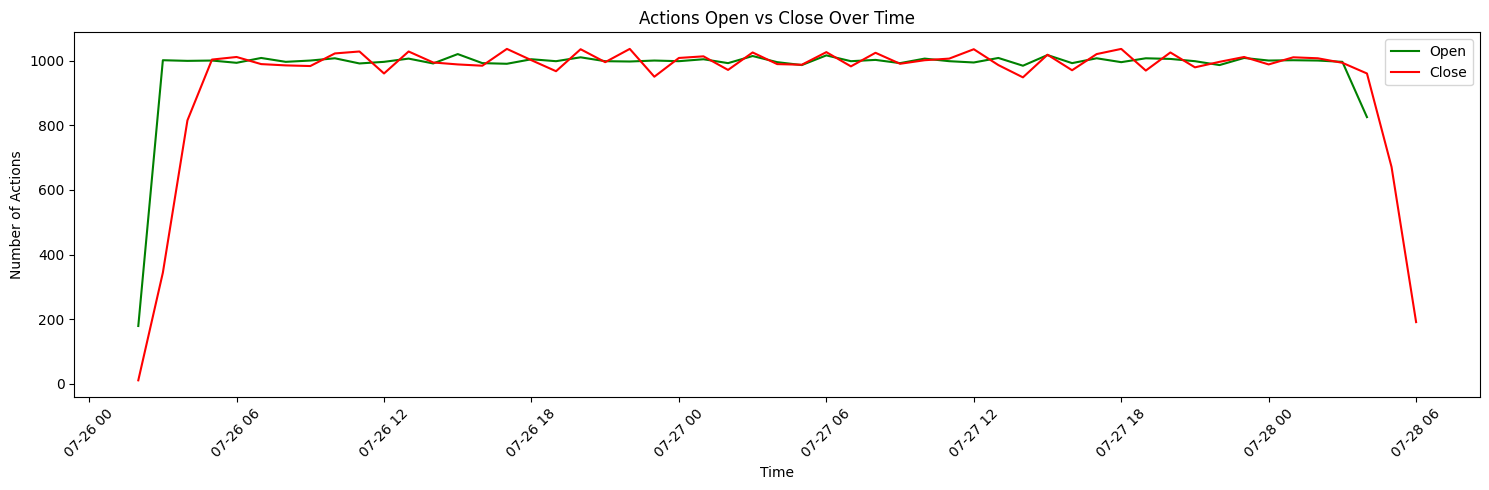

In [0]:
import matplotlib.pyplot as plt
import pandas as pd
pdf = staticCountsDF.toPandas()

pdf['start'] = pdf['window'].apply(lambda x: x['start'])


pdf['start'] = pd.to_datetime(pdf['start'])
pdf = pdf.sort_values('start')


open_df = pdf[pdf['action'] == 'Open']
close_df = pdf[pdf['action'] == 'Close']

plt.figure(figsize=(15,5))
plt.plot(open_df['start'], open_df['count'], label='Open', color='green')
plt.plot(close_df['start'], close_df['count'], label='Close', color='red')
plt.xlabel('Time')
plt.ylabel('Number of Actions')
plt.title('Actions Open vs Close Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Note the two ends of the graph. The close actions are generated such that they are after the corresponding open actions, so there are more "opens" in the beginning and more "closes" in the end.

**NOTE:** Due to the Databricks environment, it is needed to also create temp tables in the unity catalog by running the below cell before starting the streaming processing. Additionally the below cell will need to be re-run to clear out the temp tables prior to re-running any  streaming dfs.

In [0]:
# Define the name of the new catalog
catalog = 'workspace'

# define variables for the trips data
schema = 'default'
volume = 'checkpoints'

# Path for file operations
path_volume = f'/Volumes/{catalog}/{schema}/{volume}'

# Three-part names for SQL operations
path_table = f'{catalog}.{schema}'
volume_name = f'{catalog}.{schema}.{volume}'

# Drop old temp volume (use three-part name, not path)
spark.sql(f"DROP VOLUME IF EXISTS {volume_name}")

# Create new temp volume
spark.sql(f"CREATE VOLUME IF NOT EXISTS {volume_name}")

# Define tmp dir for each stream
tmp_input = f"{path_volume}/input"
tmp_streaming_counts = f"{path_volume}/streaming_counts"
tmp_streaming_counts_filter = f"{path_volume}/streaming_counts_filter"
tmp_streaming_counts_run = f"{path_volume}/streaming_counts_run"

## Demo: Stream Processing 
Now that we have analyzed the data interactively, let's convert this to a streaming query that continuously updates as data comes. Since we just have a static set of files, we are going to emulate a stream from them by reading one file at a time, in the chronological order they were created. The query we have to write is pretty much the same as the interactive query above.


In [0]:
from pyspark.sql.functions import *

# Read data from a file
# Similar to definition of staticInputDF above, just using `readStream` instead of `read`
streamingInputDF = (
  spark
    .readStream                       
    .schema(jsonSchema)               # Set the schema of the JSON data
    .option("maxFilesPerTrigger", 1)  # Treat a sequence of files as a stream by picking one file at a time
    .json(inputPath)
)

# Do some transformations
# Same query as staticInputDF
streamingCountsDF = (                 
  streamingInputDF
    .groupBy(
      streamingInputDF.action, 
      window(streamingInputDF.time, "1 hour"))
    .count()
)

# Is this DF actually a streaming DF?
streamingCountsDF.isStreaming

True

In [0]:
# Display input data
streamingInputDF.display(checkpointLocation=tmp_input)

time,action
2016-07-26T02:45:07.000Z,Open
2016-07-26T02:45:47.000Z,Open
2016-07-26T02:46:42.000Z,Open
2016-07-26T02:46:59.000Z,Open
2016-07-26T02:47:05.000Z,Open
2016-07-26T02:47:14.000Z,Open
2016-07-26T02:47:25.000Z,Open
2016-07-26T02:47:26.000Z,Open
2016-07-26T02:47:28.000Z,Open
2016-07-26T02:47:36.000Z,Open


In [0]:
# Display transformed data
streamingCountsDF.display(checkpointLocation=tmp_streaming_counts)

action,window,count
Open,"List(2016-07-27T01:00:00.000Z, 2016-07-27T02:00:00.000Z)",1004
Open,"List(2016-07-26T22:00:00.000Z, 2016-07-26T23:00:00.000Z)",997
Open,"List(2016-07-27T23:00:00.000Z, 2016-07-28T00:00:00.000Z)",1008
Open,"List(2016-07-27T20:00:00.000Z, 2016-07-27T21:00:00.000Z)",1005
Open,"List(2016-07-27T06:00:00.000Z, 2016-07-27T07:00:00.000Z)",1016
Open,"List(2016-07-26T02:00:00.000Z, 2016-07-26T03:00:00.000Z)",179
Open,"List(2016-07-28T04:00:00.000Z, 2016-07-28T05:00:00.000Z)",825
Open,"List(2016-07-26T13:00:00.000Z, 2016-07-26T14:00:00.000Z)",1006
Open,"List(2016-07-27T14:00:00.000Z, 2016-07-27T15:00:00.000Z)",984
Open,"List(2016-07-27T11:00:00.000Z, 2016-07-27T12:00:00.000Z)",998


In [0]:
# Add aditional filter to transformed dataframe
streamingCountsDF.filter(streamingCountsDF.action == 'Open').display(checkpointLocation=tmp_streaming_counts_filter)

action,window,count
Open,"List(2016-07-27T01:00:00.000Z, 2016-07-27T02:00:00.000Z)",1004
Open,"List(2016-07-26T22:00:00.000Z, 2016-07-26T23:00:00.000Z)",997
Open,"List(2016-07-27T23:00:00.000Z, 2016-07-28T00:00:00.000Z)",1008
Open,"List(2016-07-27T20:00:00.000Z, 2016-07-27T21:00:00.000Z)",1005
Open,"List(2016-07-27T06:00:00.000Z, 2016-07-27T07:00:00.000Z)",1016
Open,"List(2016-07-26T02:00:00.000Z, 2016-07-26T03:00:00.000Z)",179
Open,"List(2016-07-28T04:00:00.000Z, 2016-07-28T05:00:00.000Z)",825
Open,"List(2016-07-26T13:00:00.000Z, 2016-07-26T14:00:00.000Z)",656
Open,"List(2016-07-27T14:00:00.000Z, 2016-07-27T15:00:00.000Z)",984
Open,"List(2016-07-27T11:00:00.000Z, 2016-07-27T12:00:00.000Z)",998


As you can see, `streamingCountsDF` is a streaming Dataframe (`streamingCountsDF.isStreaming` was `true`). You can start streaming computation, by defining the sink and starting it. 
In our case, we want to interactively query the counts (same queries as above), so we will set the complete set of 1 hour counts to be in a in-memory table.

In [0]:
# Define the name of the new catalog
catalog = 'workspace'

# define variables for the trips data
schema = 'default'
volume = 'checkpoints'

# Path for file operations
path_volume = f'/Volumes/{catalog}/{schema}/{volume}'

# Three-part names for SQL operations
path_table = f'{catalog}.{schema}'
volume_name = f'{catalog}.{schema}.{volume}'

# Drop old temp volume (use three-part name, not path)
spark.sql(f"DROP VOLUME IF EXISTS {volume_name}")

# Create new temp volume
spark.sql(f"CREATE VOLUME IF NOT EXISTS {volume_name}")

# Define tmp dir for each stream
tmp_input = f"{path_volume}/input"
tmp_streaming_counts = f"{path_volume}/streaming_counts"
tmp_streaming_counts_filter = f"{path_volume}/streaming_counts_filter"
tmp_streaming_counts_run = f"{path_volume}/streaming_counts_run"

In [0]:
spark.conf.set("spark.sql.shuffle.partitions", "2")  # keep the size of shuffles small

query = (
  streamingCountsDF
    .writeStream
    .format("memory")        # memory = store in-memory table 
    .queryName("counts")     # counts = name of the in-memory table
    .option("checkpointLocation", tmp_streaming_counts_run)
    .outputMode("complete")  # complete = all the counts should be in the table
    .trigger(availableNow=True)
    .start()
)

`query` is a handle to the streaming query that is running in the background. This query is continuously picking up files and updating the windowed counts. 

Note the status of query in the above cell. The progress bar shows that the query is active. 
Furthermore, if you expand the `> counts` above, you will find the number of files they have already processed. 

Let's wait a bit for a few files to be processed and then interactively query the in-memory `counts` table.

In [0]:
%sql
SELECT *
FROM counts

action,window,count


In [0]:
from time import sleep
sleep(1)  # wait a bit for computation to start

In [0]:
%sql
select action, date_format(window.end, "MMM-dd HH:mm") as time, count
from counts
order by time, action

action,time,count
Close,Jul-26 03:00,11
Open,Jul-26 03:00,179
Close,Jul-26 04:00,344
Open,Jul-26 04:00,1001
Close,Jul-26 05:00,176
Open,Jul-26 05:00,289


We see the timeline of windowed counts (similar to the static one earlier) building up. If we keep running this interactive query repeatedly, we will see the latest updated counts which the streaming query is updating in the background.

In [0]:
sleep(1)  # wait a bit more for more data to be computed

In [0]:
%sql select action, date_format(window.end, "MMM-dd HH:mm") as time, count from counts order by time, action

action,time,count
Close,Jul-26 03:00,11
Open,Jul-26 03:00,179
Close,Jul-26 04:00,344
Open,Jul-26 04:00,1001
Close,Jul-26 05:00,815
Open,Jul-26 05:00,999
Close,Jul-26 06:00,323
Open,Jul-26 06:00,328
Close,Jul-26 14:00,699
Open,Jul-26 14:00,656


In [0]:
sleep(1)  # wait a bit more for more data to be computed

In [0]:
%sql select action, date_format(window.end, "MMM-dd HH:mm") as time, count from counts order by time, action

action,time,count
Close,Jul-26 03:00,11
Open,Jul-26 03:00,179
Close,Jul-26 04:00,344
Open,Jul-26 04:00,1001
Close,Jul-26 05:00,815
Open,Jul-26 05:00,999
Close,Jul-26 06:00,323
Open,Jul-26 06:00,328
Close,Jul-26 14:00,699
Open,Jul-26 14:00,656


Also, let's see the total number of "opens" and "closes".

In [0]:
%sql 
select action, sum(count) as total_count 
from counts 
group by action 
order by action

action,total_count
Close,8505
Open,9495


If you keep running the above query repeatedly, you will always find that the number of "opens" is more than the number of "closes", as expected in a data stream where a "close" always appear after corresponding "open". This shows that Structured Streaming ensures **prefix integrity**. Read the blog posts linked below if you want to know more.

Note that there are only a few files, so consuming all of them there will be no updates to the counts. Rerun the query if you want to interact with the streaming query again.

Finally, you can stop the query running in the background, either by clicking on the 'Cancel' link in the cell of the query, or by executing `query.stop()`. Either way, when the query is stopped, the status of the corresponding cell above will automatically update to `TERMINATED`.

In [0]:
query.stop()

### IoT data

Develop a streaming example on `IoT device`dataset:

- inspect the dataset
- ask yourself couple of questions about the data and try to answer them (eg. how many steps users do, how many calories do they burn...)
- you read the data in streaming fashion (file by file) and keep the data for only one company? Here are some hints:
  - you can find the schema in the readme file 
  - as above, use this option: .option("maxFilesPerTrigger", 1)
  - use user_id or device_id for grouping
  - use timestamp for window definition
  - you can try streaming joins with the user data (/databricks-datasets/iot-stream/data-user/userData.csv). Here is the doc: https://spark.apache.org/docs/latest/structured-streaming-programming-guide.html#join-operations

In [0]:
# Iot stream dataset
display(dbutils.fs.ls('/databricks-datasets/iot-stream/'))

path,name,size,modificationTime
dbfs:/databricks-datasets/iot-stream/README.md,README.md,1596,1596565744000
dbfs:/databricks-datasets/iot-stream/data-device/,data-device/,0,1763327239482
dbfs:/databricks-datasets/iot-stream/data-user/,data-user/,0,1763327239482


In [0]:
# Read the README file
dbutils.fs.head('/databricks-datasets/iot-stream/README.md')

'==========================================\r\nIOT Device Data\r\n==========================================\r\n\r\n\r\nThis dataset was created by Databricks.  \r\nIt contains fake generated data in json and csv formats. \r\ne.g. \r\n`{"user_id": 12, "calories_burnt": 489.79998779296875, "num_steps": 9796, "miles_walked": 4.8979997634887695, "time_stamp": "2018-07-24 03:54:00.893775", "device_id": 10}`\r\n\r\n=========================================\r\nData Set Information\r\n=========================================\r\n\r\nSchema for data-device:\r\n```\r\n[StructField(id,LongType,false),  \r\n StructField(user_id,LongType,true),  \r\n StructField(device_id,LongType,true),  \r\n StructField(num_steps,LongType,true),  \r\n StructField(miles_walked,FloatType,true),  \r\n StructField(calories_burnt,FloatType,true),  \r\n StructField(timestamp,StringType,true),  \r\n StructField(value,StringType,true)]  \r\n```\r\n\r\nSchema for data-user:\r\n```\r\n[StructField(userid,IntegerType,true)

In [0]:
# Define the schema (copy from the README) data-device
from pyspark.sql.types import StructType, StructField, LongType, FloatType, StringType

device_schema = StructType([
    StructField("id", LongType(), nullable=False),
    StructField("user_id", LongType(), nullable=True),
    StructField("device_id", LongType(), nullable=True),
    StructField("num_steps", LongType(), nullable=True),
    StructField("miles_walked", FloatType(), nullable=True),
    StructField("calories_burnt", FloatType(), nullable=True),
    StructField("timestamp", StringType(), nullable=True),
    StructField("value", StringType(), nullable=True)
])

In [0]:
# Open one file to see how the data looks like (as a static dataframe)
df = spark.read.schema(device_schema).json("dbfs:/databricks-datasets/iot-stream/data-device/")

In [0]:
df.display()

id,user_id,device_id,num_steps,miles_walked,calories_burnt,timestamp,value
950000,24,5,5014,2.507,250.7,2018-07-22 06:44:25.732267,"{""user_id"": 24, ""calories_burnt"": 250.6999969482422, ""num_steps"": 5014, ""miles_walked"": 2.506999969482422, ""time_stamp"": ""2018-07-22 06:44:25.732267"", ""device_id"": 5}"
950001,24,13,2536,1.268,126.8,2018-07-21 01:18:10.732306,"{""user_id"": 24, ""calories_burnt"": 126.80000305175781, ""num_steps"": 2536, ""miles_walked"": 1.2680000066757202, ""time_stamp"": ""2018-07-21 01:18:10.732306"", ""device_id"": 13}"
950002,4,5,7314,3.657,365.7,2018-07-24 12:42:53.732332,"{""user_id"": 4, ""calories_burnt"": 365.70001220703125, ""num_steps"": 7314, ""miles_walked"": 3.6570000648498535, ""time_stamp"": ""2018-07-24 12:42:53.732332"", ""device_id"": 5}"
950003,22,10,9796,4.898,489.8,2018-07-23 22:56:23.732358,"{""user_id"": 22, ""calories_burnt"": 489.79998779296875, ""num_steps"": 9796, ""miles_walked"": 4.8979997634887695, ""time_stamp"": ""2018-07-23 22:56:23.732358"", ""device_id"": 10}"
950004,34,13,5603,2.8015,280.15,2018-07-21 13:50:39.732385,"{""user_id"": 34, ""calories_burnt"": 280.1499938964844, ""num_steps"": 5603, ""miles_walked"": 2.801500082015991, ""time_stamp"": ""2018-07-21 13:50:39.732385"", ""device_id"": 13}"
950005,21,1,11832,5.916,591.6,2018-07-23 11:05:48.732412,"{""user_id"": 21, ""calories_burnt"": 591.5999755859375, ""num_steps"": 11832, ""miles_walked"": 5.915999889373779, ""time_stamp"": ""2018-07-23 11:05:48.732412"", ""device_id"": 1}"
950006,7,12,10962,5.481,548.1,2018-07-23 02:10:39.732438,"{""user_id"": 7, ""calories_burnt"": 548.0999755859375, ""num_steps"": 10962, ""miles_walked"": 5.480999946594238, ""time_stamp"": ""2018-07-23 02:10:39.732438"", ""device_id"": 12}"
950007,33,4,5448,2.724,272.4,2018-07-22 17:42:18.732465,"{""user_id"": 33, ""calories_burnt"": 272.3999938964844, ""num_steps"": 5448, ""miles_walked"": 2.7239999771118164, ""time_stamp"": ""2018-07-22 17:42:18.732465"", ""device_id"": 4}"
950008,16,5,7637,3.8185,381.85,2018-07-21 12:21:21.732491,"{""user_id"": 16, ""calories_burnt"": 381.8500061035156, ""num_steps"": 7637, ""miles_walked"": 3.81850004196167, ""time_stamp"": ""2018-07-21 12:21:21.732491"", ""device_id"": 5}"
950009,27,8,11709,5.8545,585.44995,2018-07-22 12:40:55.732517,"{""user_id"": 27, ""calories_burnt"": 585.449951171875, ""num_steps"": 11709, ""miles_walked"": 5.854499816894531, ""time_stamp"": ""2018-07-22 12:40:55.732517"", ""device_id"": 8}"


In [0]:
# Define your streaming dataframe
streamingDeviceDF = (
    spark.readStream
         .schema(device_schema)  # Utilise le schema défini
         .json("dbfs:/databricks-datasets/iot-stream/data-device/")  # dossier source
)

In [0]:
# Define your transformations
from pyspark.sql.functions import col, window, sum as spark_sum
windowedCountsDF = (
    streamingDeviceDF
        .groupBy(
            col("user_id"),
            window(col("timestamp"), "1 hour")  # fenêtre de 1 heure
        )
        .agg(
            spark_sum("num_steps").alias("total_steps"),
            spark_sum("calories_burnt").alias("total_calories")
        )
)

In [0]:
# Define the name of the new catalog
catalog = 'workspace'

# define variables for the trips data
schema = 'default'
volume = 'checkpoints'

# Path for file operations
path_volume = f'/Volumes/{catalog}/{schema}/{volume}'

# Three-part names for SQL operations
path_table = f'{catalog}.{schema}'
volume_name = f'{catalog}.{schema}.{volume}'

# Drop old temp volume (use three-part name, not path)
spark.sql(f"DROP VOLUME IF EXISTS {volume_name}")

# Create new temp volume
spark.sql(f"CREATE VOLUME IF NOT EXISTS {volume_name}")

# Define tmp dir for each stream
tmp_input = f"{path_volume}/input"
tmp_streaming_counts = f"{path_volume}/streaming_counts"
tmp_streaming_counts_filter = f"{path_volume}/streaming_counts_filter"
tmp_streaming_counts_run = f"{path_volume}/streaming_counts_run2"

In [0]:
# Define the sink and start streaming 
spark.conf.set("spark.sql.shuffle.partitions", "2")  # keep the size of shuffles small




query = (
  windowedCountsDF
    .writeStream
    .format("memory")        # memory = store in-memory table 
    .queryName("windowed_counts")     # counts = name of the in-memory table
    .option("checkpointLocation", tmp_streaming_counts_run)
    .outputMode("complete")  # complete = all the counts should be in the table
    .trigger(availableNow=True)
    .start()
)

In [0]:
query.isActive


False

In [0]:
%sql
-- visualize your streaming analytics
SELECT * FROM windowed_counts
LIMIT 20

user_id,window,total_steps,total_calories
